In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import quantax as qtx
from IPython.display import clear_output

### ED


(1, 4, 4)


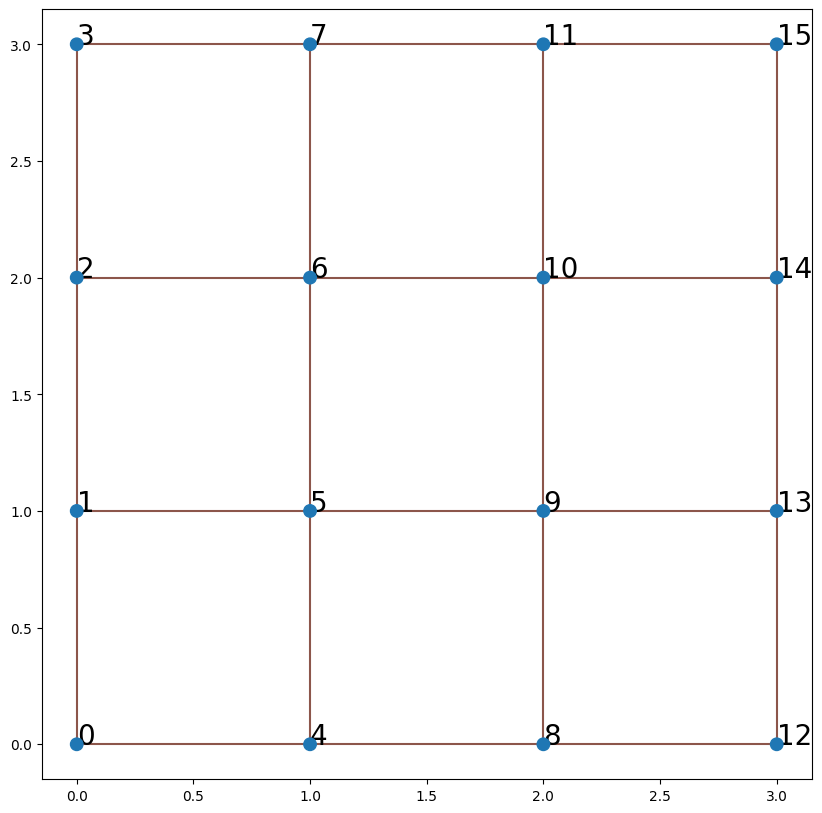

In [2]:
# 4x4 square lattice, PBC by default, 8 spin-up, 8 spin-down
lattice = qtx.sites.Square(4, Nparticles=(8, 8))

print(lattice.shape)  # output: (1, 4, 4), 1 spin per unit cell, and Lx = Ly = 4
lattice.plot()
plt.show()

In [3]:
# Define Heisenberg Hamiltonian

# Method 1: Using built-in operator
H = qtx.operator.Heisenberg()


# Method2: Customized operator
from quantax.operator import sigma_m, sigma_p, sigma_z

H = 0

Lx, Ly = lattice.shape[1:]
for x in range(Lx):
    for y in range(Ly):
        # Periodic boundary taken into account automatically
        H += sigma_z(x, y) @ sigma_z(x + 1, y) + sigma_z(x, y) @ sigma_z(x, y + 1)
        H += 2 * (sigma_m(x, y) @ sigma_p(x + 1, y) + sigma_p(x, y) @ sigma_m(x + 1, y))
        H += 2 * (sigma_m(x, y) @ sigma_p(x, y + 1) + sigma_p(x, y) @ sigma_m(x, y + 1))

print(H)

+4.0 Sᶻ₀ Sᶻ₄ +4.0 Sᶻ₀ Sᶻ₁ +4.0 Sᶻ₁ Sᶻ₅ +4.0 Sᶻ₁ Sᶻ₂ +4.0 Sᶻ₂ Sᶻ₆ +4.0 Sᶻ₂ Sᶻ₃ +4.0 Sᶻ₃ Sᶻ₇ +4.0 Sᶻ₃ Sᶻ₀ +4.0 Sᶻ₄ Sᶻ₈ +4.0 Sᶻ₄ Sᶻ₅ +4.0 Sᶻ₅ Sᶻ₉ +4.0 Sᶻ₅ Sᶻ₆ +4.0 Sᶻ₆ Sᶻ₁₀ +4.0 Sᶻ₆ Sᶻ₇ +4.0 Sᶻ₇ Sᶻ₁₁ +4.0 Sᶻ₇ Sᶻ₄ +4.0 Sᶻ₈ Sᶻ₁₂ +4.0 Sᶻ₈ Sᶻ₉ +4.0 Sᶻ₉ Sᶻ₁₃ +4.0 Sᶻ₉ Sᶻ₁₀ +4.0 Sᶻ₁₀ Sᶻ₁₄ +4.0 Sᶻ₁₀ Sᶻ₁₁ +4.0 Sᶻ₁₁ Sᶻ₁₅ +4.0 Sᶻ₁₁ Sᶻ₈ +4.0 Sᶻ₁₂ Sᶻ₀ +4.0 Sᶻ₁₂ Sᶻ₁₃ +4.0 Sᶻ₁₃ Sᶻ₁ +4.0 Sᶻ₁₃ Sᶻ₁₄ +4.0 Sᶻ₁₄ Sᶻ₂ +4.0 Sᶻ₁₄ Sᶻ₁₅ +4.0 Sᶻ₁₅ Sᶻ₃ +4.0 Sᶻ₁₅ Sᶻ₁₂ +2.0 S⁻₀ S⁺₄ +2.0 S⁻₀ S⁺₁ +2.0 S⁻₁ S⁺₅ +2.0 S⁻₁ S⁺₂ +2.0 S⁻₂ S⁺₆ +2.0 S⁻₂ S⁺₃ +2.0 S⁻₃ S⁺₇ +2.0 S⁻₃ S⁺₀ +2.0 S⁻₄ S⁺₈ +2.0 S⁻₄ S⁺₅ +2.0 S⁻₅ S⁺₉ +2.0 S⁻₅ S⁺₆ +2.0 S⁻₆ S⁺₁₀ +2.0 S⁻₆ S⁺₇ +2.0 S⁻₇ S⁺₁₁ +2.0 S⁻₇ S⁺₄ +2.0 S⁻₈ S⁺₁₂ +2.0 S⁻₈ S⁺₉ +2.0 S⁻₉ S⁺₁₃ +2.0 S⁻₉ S⁺₁₀ +2.0 S⁻₁₀ S⁺₁₄ +2.0 S⁻₁₀ S⁺₁₁ +2.0 S⁻₁₁ S⁺₁₅ +2.0 S⁻₁₁ S⁺₈ +2.0 S⁻₁₂ S⁺₀ +2.0 S⁻₁₂ S⁺₁₃ +2.0 S⁻₁₃ S⁺₁ +2.0 S⁻₁₃ S⁺₁₄ +2.0 S⁻₁₄ S⁺₂ +2.0 S⁻₁₄ S⁺₁₅ +2.0 S⁻₁₅ S⁺₃ +2.0 S⁻₁₅ S⁺₁₂ +2.0 S⁺₀ S⁻₄ +2.0 S⁺₀ S⁻₁ +2.0 S⁺₁ S⁻₅ +2.0 S⁺₁ S⁻₂ +2.0 S⁺₂ S⁻₆ +2.0 S⁺₂ S⁻₃ +2.0 S⁺₃ S⁻₇ +2.0 S⁺₃ S⁻₀ +2.0 S⁺₄ S⁻₈ +2.

In [4]:
E, wf = H.diagonalize(k=2)

dense0 = qtx.state.DenseState(wf[:, 0])  # Ground state
dense1 = qtx.state.DenseState(wf[:, 1])  # First excited state

/Users/awwabaliazam/Documents/YuGroupResearch/NN_Discrete/.venv/lib/python3.12/site-packages/quspin/tools/misc.py:184: SyntaxWarning: invalid escape sequence '\m'
  """Calculates the mean-level spacing of an energy spectrum.
/Users/awwabaliazam/Documents/YuGroupResearch/NN_Discrete/.venv/lib/python3.12/site-packages/quspin/operators/hamiltonian_core.py:188: SyntaxWarning: invalid escape sequence '\c'
  """Constructs time-dependent (hermitian and nonhermitian) operators.


In [5]:
s = qtx.utils.rand_states()
print("s =", s)  # +1/-1 represents spin-up/down
print("<s|psi0> =", dense0(s))

s = [ 1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1 -1  1 -1]
<s|psi0> = [-0.00286136]


In [6]:
print("<psi0|psi0> =", dense0 @ dense0)  # output: 1, normalization
print("<psi0|psi1> =", dense0 @ dense1)  # output: 0, orthogonality

print("<psi0|H|psi0> =", dense0 @ H @ dense0, "\t", "E0 =", E[0])
print("<psi1|H|psi1> =", dense1 @ H @ dense1, "\t", "E1 =", E[1])

<psi0|psi0> = 0.9999999999999984
<psi0|psi1> = 2.7755575615628914e-16
<psi0|H|psi0> = -44.913932833715364 	 E0 = -44.91393283371536
<psi1|H|psi1> = -42.59953949065384 	 E1 = -42.59953949065379


In [7]:
def correlation(i, j):
    # sigma_z(x, y) and sigma_z(i) with i=4x+y are equivalent in 4x4 lattice
    return (
        sigma_z(i) @ sigma_z(j)
        + 2 * sigma_p(i) @ sigma_m(j)
        + 2 * sigma_m(i) @ sigma_p(j)
    ) / 4


C1 = correlation(0, 1)
C2 = correlation(0, 2)

print("<C01> =", dense0 @ C1 @ dense0)
print("<C02> =", dense0 @ C2 @ dense0)

<C01> = -0.3508901002634015
<C02> = 0.2137652853994257


In [8]:
from quantax.symmetry import C4v, SpinInverse, TransND

# The symmetry superposition can be performed by "@"
symm = TransND() @ C4v() @ SpinInverse()

# We will get "GeneralBasisWarning" from QuSpin, but it doesn't matter here
E0_symm, wf0_symm = H.diagonalize(symm)
dense0_symm = qtx.state.DenseState(wf0_symm, symm)

/Users/awwabaliazam/Documents/YuGroupResearch/NN_Discrete/.venv/lib/python3.12/site-packages/quantax/symmetry/symmetry.py:288: GeneralBasisWarning: using non-commuting symmetries can lead to unwanted behaviour of general basis, make sure that quantum numbers are invariant under non-commuting symmetries!
  basis = spin_basis_general(


In [9]:
print("E0 =", E0_symm)
print("Check overlap:", dense0_symm @ dense0)
print("<s|psi0> =", dense0_symm(s))
print("<psi0|H|psi0> =", dense0_symm @ H @ dense0_symm)

E0 = [-44.91393283]
Check overlap: 0.9999999999999996
<s|psi0> = [-0.00286136]
<psi0|H|psi0> = -44.91393283371546


In [10]:
print("Wrong <C01>:", dense0_symm @ C1 @ dense0_symm)
print("Wrong <C02>:", dense0_symm @ C2 @ dense0_symm)

Wrong <C01>: 0.1507402593085023
Wrong <C02>: 0.23714288042475284


In [11]:
spin_inv = SpinInverse(-1)

E1_symm, wf1_symm = H.diagonalize(spin_inv)
print("Excited state energy =", E1_symm)  # It's the first excited state shown above

dense1_symm = qtx.state.DenseState(wf1_symm, spin_inv)
print("Check overlap:", dense1_symm @ dense1)

Excited state energy = [-42.59953949]
Check overlap: 1.0000000000000013


### NQS


In [12]:
# 4x4 square lattice, 8 spin-up, 8 spin-down
lattice = qtx.sites.Square(4, Nparticles=(8, 8))
N = lattice.Nsites

/Users/awwabaliazam/Documents/YuGroupResearch/NN_Discrete/.venv/lib/python3.12/site-packages/quantax/sites/sites.py:47: UserWarning: Quantax treats the `Sites` as a global constant.Defining multiple `Sites` might lead to unexpected behaviors.
  warn(


In [13]:
H = qtx.operator.Heisenberg(msr=True)

In [14]:
from quantax.symmetry import Flip, Rotation, SpinInverse, TransND

full_symm = TransND() @ Rotation(np.pi / 2) @ Flip() @ SpinInverse()
E, wf = H.diagonalize(full_symm)
exact_energy = E[0]
print(f"Exact ground state energy: {exact_energy}")

Exact ground state energy: -44.91393283371545


In [24]:
model = qtx.model.ResConv(nblocks=2, channels=8, kernel_size=3)

In [25]:
state = qtx.state.Variational(model, max_parallel=25000)

In [26]:
sampler = qtx.sampler.SpinExchange(state, nsamples=1024)
optimizer = qtx.optimizer.SR(state, H)

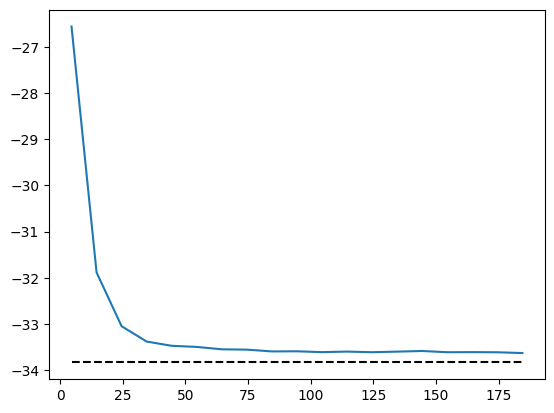

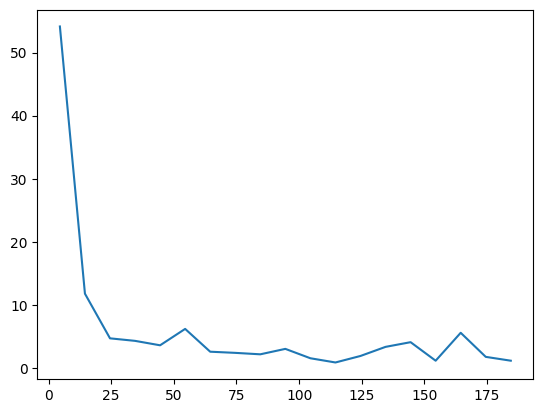

In [27]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

training_rate = 0.01

for i in range(200):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * training_rate)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)
    if i % 10 == 0:
        clear_output()
        energy.plot(batch=10, baseline=exact_energy)
        plt.show()
        VarE.plot(batch=10)
        plt.show()

In [28]:
state.save("/tmp/Heisenberg.eqx")

In [29]:
symm = Rotation(np.pi / 2) @ Flip() @ SpinInverse()

symm_state = qtx.state.Variational(
    model, "/tmp/Heisenberg.eqx", symm, max_parallel=2048
)

sampler = qtx.sampler.SpinExchange(symm_state, nsamples=1024)
optimizer = qtx.optimizer.SR(symm_state, H)

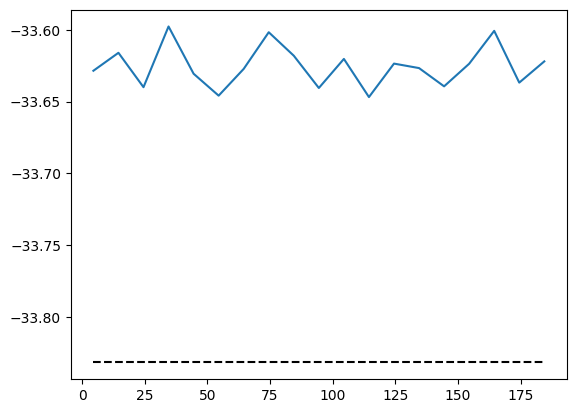

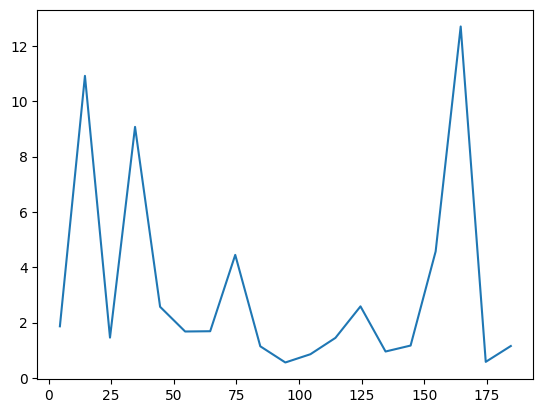

In [30]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

training_rate = 0.01

for i in range(200):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * training_rate)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)
    if i % 10 == 0:
        clear_output()
        energy.plot(batch=10, baseline=exact_energy)
        plt.show()
        VarE.plot(batch=10)
        plt.show()

state.save("/tmp/Heisenberg.eqx")

In [31]:
H = qtx.operator.Heisenberg(J=[1, 0.5], n_neighbor=[1, 2], msr=True)

full_symm = TransND() @ Rotation(np.pi / 2) @ Flip() @ SpinInverse()
E, wf = H.diagonalize(full_symm)
exact_energy = E[0]
print(f"Exact ground state energy: {exact_energy}")

Exact ground state energy: -33.83169340557941


/Users/awwabaliazam/Documents/YuGroupResearch/NN_Discrete/.venv/lib/python3.12/site-packages/quantax/symmetry/symmetry.py:288: GeneralBasisWarning: using non-commuting symmetries can lead to unwanted behaviour of general basis, make sure that quantum numbers are invariant under non-commuting symmetries!
  basis = spin_basis_general(


In [32]:
model = qtx.model.ResConv(
    nblocks=2, channels=8, kernel_size=3, final_activation=qtx.nn.sinhp1_by_scale
)

state = qtx.state.Variational(model, max_parallel=20000)
sampler = qtx.sampler.SpinExchange(state, nsamples=1024)
optimizer = qtx.optimizer.SR(state, H)

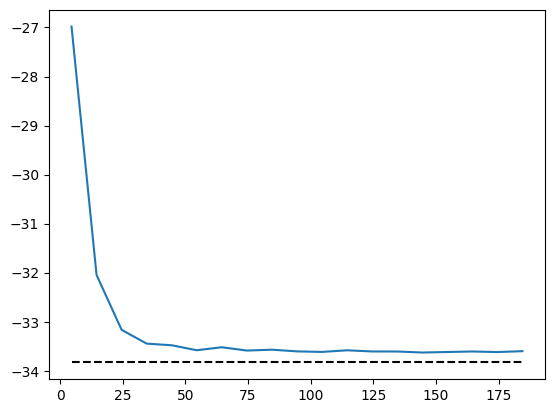

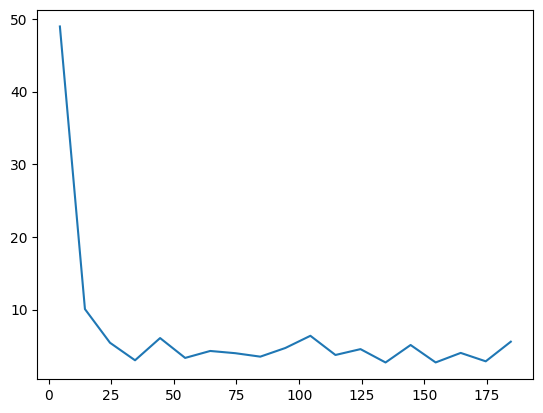

In [33]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

training_rate = 0.01

for i in range(200):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * training_rate)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)
    if i % 10 == 0:
        clear_output()
        energy.plot(batch=10, baseline=exact_energy)
        plt.show()
        VarE.plot(batch=10)
        plt.show()

state.save("/tmp/J1J2.eqx")

In [34]:
symm = Rotation(np.pi / 2) @ Flip() @ SpinInverse()

symm_state = qtx.state.Variational(model, "/tmp/J1J2.eqx", symm, max_parallel=2048)

sampler = qtx.sampler.SpinExchange(symm_state, nsamples=1024)
optimizer = qtx.optimizer.SR(symm_state, H)

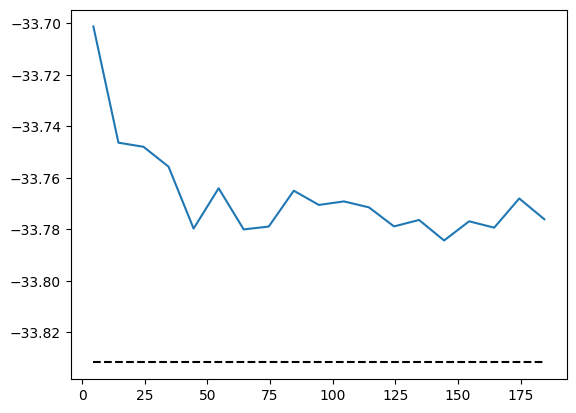

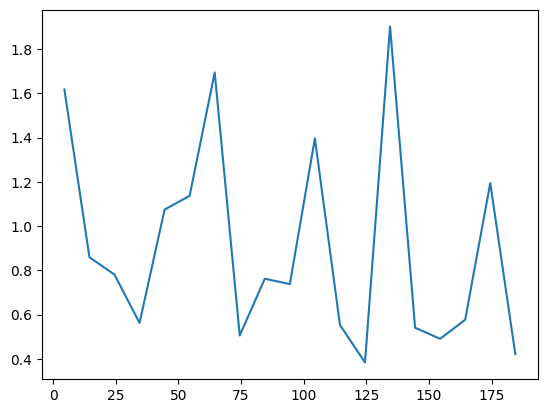

In [35]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

training_rate = 0.01

for i in range(200):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    symm_state.update(step * training_rate)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)
    if i % 10 == 0:
        clear_output()
        energy.plot(batch=10, baseline=exact_energy)
        plt.show()
        VarE.plot(batch=10)
        plt.show()

symm_state.save("/tmp/J1J2.eqx")

In [36]:
dense = symm_state.todense(full_symm).normalize()
nqs_energy = jnp.asarray(dense @ H @ dense)
rel_err = jnp.abs((nqs_energy - exact_energy) / exact_energy)
print(f"NQS energy: {nqs_energy}, relative error: {rel_err}")

fidelity = jnp.abs(dense @ wf[:, 0]) ** 2
print(f"Fidelity: {fidelity}")

NQS energy: -33.79103201811904, relative error: 0.0012018726633903022
Fidelity: 0.9974340446418912
